<a href="https://colab.research.google.com/github/Amyerm/ClassFiles/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Ari Daniel Mendoza Enrriquez
- **Matrícula:** 271756

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [2]:
# Calcular medidas de tendencia central de price
media_price = df['price'].mean()
mediana_price = df['price'].median()
moda_price = df['price'].mode()[0]

print("Media:", round(media_price, 2))
print("Mediana:", mediana_price)
print("Moda:", moda_price)

Media: 152.72
Mediana: 106.0
Moda: 100


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_ La media de price es 152.72, mientras que la mediana es 106, por lo que existe una diferencia de 46.72 dólares entre ambas. La media también se encuentra por encima de la moda, que es 100. Al igual que se observó con Income en clase, esta diferencia sugiere que existen algunos valores muy altos que elevan la media. Es probable que la distribución tenga valores extremos hacia la derecha y que la mediana represente mejor el precio típico de los alojamientos.

---
## Actividad 2 — Dispersión (20 pts)

In [3]:
# Calcular rango de precios
precio_minimo = df['price'].min()
precio_maximo = df['price'].max()
rango = precio_maximo - precio_minimo

# Calcular varianza y desviación estándar
varianza = df['price'].var()
desviacion_estandar = df['price'].std()

# Calcular los cuartiles y el rango intercuartílico
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

print("Precio mínimo:", precio_minimo)
print("Precio máximo:", precio_maximo)
print("Rango:", rango)
print("Varianza:", round(varianza, 2))
print("Desviación estándar:", round(desviacion_estandar, 2))
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)

Precio mínimo: 0
Precio máximo: 10000
Rango: 10000
Varianza: 57674.03
Desviación estándar: 240.15
Q1: 69.0
Q3: 175.0
IQR: 106.0


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_ El rango de price es 10,000, debido a que el precio mínimo es 0 y el máximo es 10,000. En cambio, el IQR es 106, con un Q1 de 69 y un Q3 de 175. El IQR representa mejor la dispersión típica de los precios, porque describe la amplitud del 50 % central de los datos y no se ve afectado directamente por los valores extremos. El rango resulta muy grande principalmente por el precio máximo de 10,000, por lo que no refleja adecuadamente la variación de la mayoría de los alojamientos.

---
## Actividad 3 — Forma (20 pts)

In [4]:
# Calcular las medidas de forma de price
asimetria = df['price'].skew()
curtosis = df['price'].kurt()

print("Asimetría:", round(asimetria, 2))
print("Curtosis:", round(curtosis, 2))

Asimetría: 19.12
Curtosis: 585.67


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_ La columna price tiene una asimetría positiva de 19.12, considerablemente mayor que la asimetría de 6.76 en Income. Los precios presentan una cola mucho más extensa hacia la derecha debido a algunos valores muy altos. Su curtosis también es mayor: price tiene 585.67, mientras que Income tenía 159.6. Esto muestra que la distribución de precios tiene valores extremos todavía más marcados, en la siguiente etapa sobre datos atípicos esperaría encontrar varios alojamientos con precios muy alejados del grupo principal, especialmente por encima de los límites habituales.

---
## Actividad 4 — Visualización (30 pts)

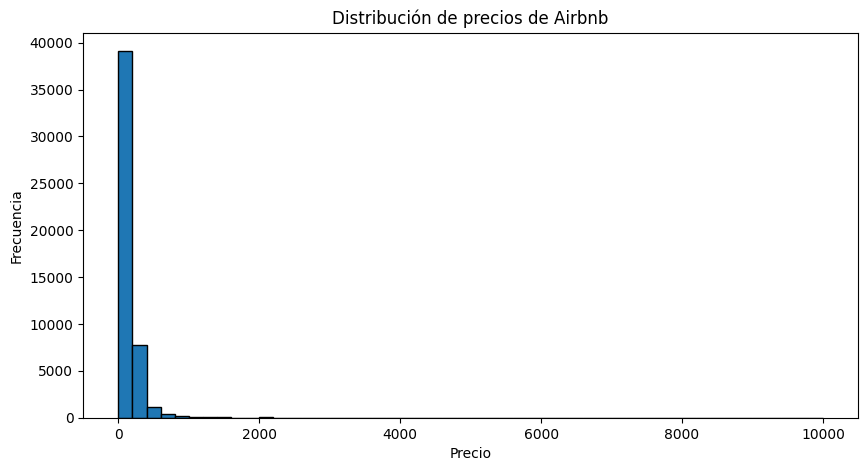

In [5]:
# Elegi 50 bins porque el dataset tiene muchos registros
# y con 50 permite observar la concentración y la cola de los precios.
df['price'].plot(
    kind='hist',
    bins=50,
    edgecolor='black',
    figsize=(10, 5)
)

plt.title('Distribución de precios de Airbnb')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

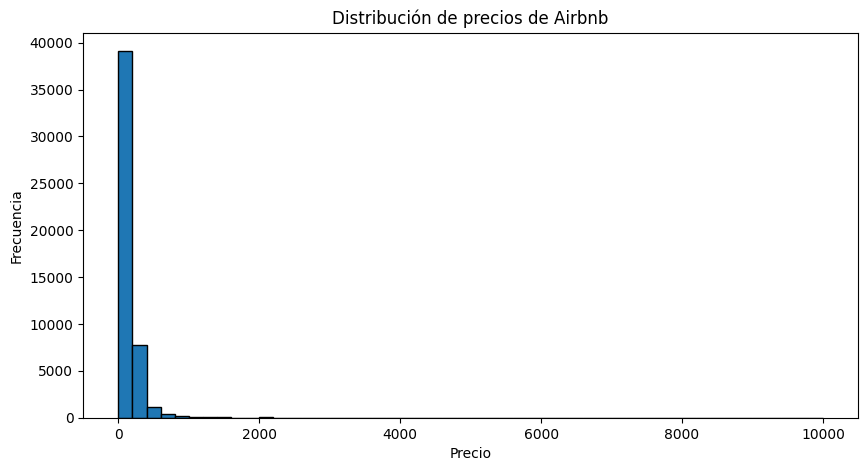

In [7]:
# Se utilizan los mismos 50 bins para comparar esta gráfica con el histograma.
plt.figure(figsize=(10, 5))

plt.hist(
    df['price'],
    bins=50,
    edgecolor='black'
)

plt.title('Distribución de precios de Airbnb')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

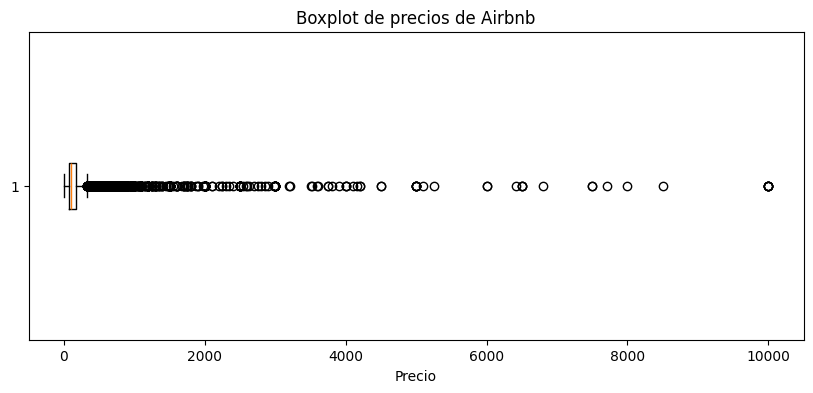

In [8]:
# Boxplot permite observar la mediana, los cuartiles
# y los valores que se encuentran fuera de los bigotes.
plt.figure(figsize=(10, 4))

plt.boxplot(df['price'], vert=False)

plt.title('Boxplot de precios de Airbnb')
plt.xlabel('Precio')
plt.show()

**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_ En los histogramas se observa que la mayoría de los precios se concentra en la parte baja de la distribución, mientras que existe una cola larga hacia la derecha causada por precios muy elevados. Los valores atípicos están presentes en el histograma como observaciones alejadas de la concentración principal, aunque no se distinguen individualmente con facilidad. En el boxplot se identifican mejor porque aparecen como puntos separados después del bigote superior. Este comportamiento coincide con la asimetría positiva de 19.12 y la curtosis de 585.67, ya que ambos valores indican una distribución con una cola derecha muy extensa y con numerosos valores extremos.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_ El precio promedio de 152.72 dólares puede ser engañoso porque existen algunos alojamientos con precios muy altos que elevan la media. La mediana es de 106 dólares y la moda es de 100, por lo que estas medidas muestran que el precio típico se encuentra más cerca de 100 dólares que de 152.72. El precio máximo llega a 10,000 dólares y la asimetría es de 19.12, lo que confirma que la distribución tiene una cola extensa hacia los precios altos. Utilizaría principalmente la mediana para describir el precio habitual de los alojamientos.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |